In [2]:
import numpy as np

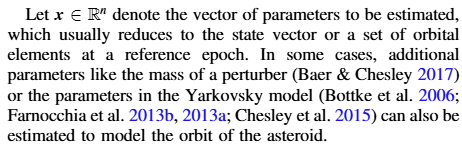

In [3]:
import requests

response = requests.get("https://data.minorplanetcenter.net/api/get-orb", json={"desig": "Eros"})

if response.ok:
    orb = response.json()[0]['mpc_orb']
else:
    print("Error: ", response.status_code, response.content)

In [4]:
print(orb[0].keys())
print(orb[0]['CAR'].keys())
print(orb[0]['COM'].keys())
print(orb[0]['categorization'].keys())
print(orb[0]['designation_data'].keys())
print(orb[0]['designation_data'].keys())
print(orb[0]['epoch_data'].keys())
print(orb[0]['magnitude_data'].keys())
print(orb[0]['moid_data'].keys())
print(orb[0]['non_grav_booleans'].keys())
print(orb[0]['orbit_fit_statistics'].keys())
print(orb[0]['software_data'].keys())
print(orb[0]['system_data'].keys())

dict_keys(['CAR', 'COM', 'categorization', 'designation_data', 'epoch_data', 'magnitude_data', 'moid_data', 'non_grav_booleans', 'orbit_fit_statistics', 'software_data', 'system_data'])
dict_keys(['coefficient_names', 'coefficient_uncertainties', 'coefficient_values', 'covariance', 'eigenvalues'])
dict_keys(['coefficient_names', 'coefficient_uncertainties', 'coefficient_values', 'covariance', 'eigenvalues'])
dict_keys(['object_type_int', 'object_type_str', 'orbit_subtype_int', 'orbit_subtype_str', 'orbit_type_int', 'orbit_type_str'])
dict_keys(['designation_count', 'iau_name', 'name', 'new_style_packed_secondary_provisional_designations', 'orbfit_name', 'packed_primary_provisional_designation', 'packed_secondary_provisional_designations', 'permid', 'unpacked_primary_provisional_designation', 'unpacked_secondary_provisional_designations'])
dict_keys(['designation_count', 'iau_name', 'name', 'new_style_packed_secondary_provisional_designations', 'orbfit_name', 'packed_primary_provisional

In [5]:
print(orb[0]['system_data']['refframe'])
print(orb[0]['system_data']['refsys'])

ICRF
Ecliptic


In [6]:
orbital_elements = orb[0]['CAR']['coefficient_values']
x = np.array(orbital_elements)

In [7]:
AU_to_km = 1.495978707e8
day_to_sec = 86400.0

In [8]:
x[:3] *= AU_to_km
x[3:] *= AU_to_km / day_to_sec

In [9]:
print(x)

[ 1.20144699e+08  1.48565328e+08  3.49924625e+07 -2.41244768e+01
  1.30481711e+01 -2.40794861e+00]


In [10]:
t0_mjd = orb[0]['epoch_data']['epoch']

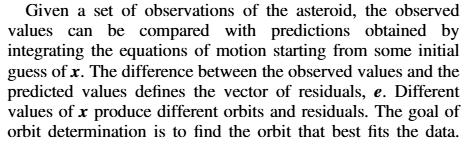

In [11]:
import spiceypy as sp

# The meta kernel file contains entries pointing to the following SPICE kernels, which the user needs to download.
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440s.bsp
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_000101_260619_260323.bpc
#   https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_latest_high_prec.bpc

#   The following is the contents of a metakernel that was saved with
#   the name 'cassMetaK.txt'.
#   \begindata
#   KERNELS_TO_LOAD=(
#     'naif0012.tls',
#     'de440s.bsp',
#     'earth_000101_260619_260323.bpc',
#     'earth_latest_high_prec.bpc',
#   )
#   \begintext

sp.furnsh("./planetaryMetaK.txt")

In [12]:
help(sp.spkezr)

Help on function spkezr in module spiceypy.spiceypy:

spkezr(targ: str, et: Union[ndarray, float], ref: str, abcorr: str, obs: str) -> Union[Tuple[ndarray, float], Tuple[Iterable[ndarray], Iterable[float]]]
    Return the state (position and velocity) of a target body
    relative to an observing body, optionally corrected for light
    time (planetary aberration) and stellar aberration.

    https://naif.jpl.nasa.gov/pub/naif/misc/toolkit_docs_N0067/C/cspice/spkezr_c.html

    :param targ: Target body name.
    :param et: Observer epoch in seconds past J2000 TDB.
    :param ref: Reference frame of output state vector.
    :param abcorr: Aberration correction flag.
    :param obs: Observing body name.
    :return:
            State of target in km and km/sec,
            One way light time between observer and target in seconds.



In [13]:
sun_radius = 695700 #km
sun_mu = 1.32712440018e11  # km^3/s^2

In [14]:
def two_body_ode(t, state):
    
    '''
    Newtons Universal Law of Gravitation
    '''
    
    r = state[:3]
    v = state[3:]
    r_norm = np.linalg.norm(r)
    a = -sun_mu * r / r_norm**3
    
    return np.concatenate((v, a))

In [15]:
from scipy.integrate import solve_ivp

In [16]:
help(solve_ivp)

Help on function solve_ivp in module scipy.integrate._ivp.ivp:

solve_ivp(
    fun,
    t_span,
    y0,
    method='RK45',
    t_eval=None,
    dense_output=False,
    events=None,
    vectorized=False,
    args=None,
    **options
)
    Solve an initial value problem for a system of ODEs.

    This function numerically integrates a system of ordinary differential
    equations given an initial value::

        dy / dt = f(t, y)
        y(t0) = y0

    Here t is a 1-D independent variable (time), y(t) is an
    N-D vector-valued function (state), and an N-D
    vector-valued function f(t, y) determines the differential equations.
    The goal is to find y(t) approximately satisfying the differential
    equations, given an initial value y(t0)=y0.

    Some of the solvers support integration in the complex domain, but note
    that for stiff ODE solvers, the right-hand side must be
    complex-differentiable (satisfy Cauchy-Riemann equations [11]_).
    To solve a problem in the complex

In [17]:
def propagate(x, t0, ti):
    sol = solve_ivp(
        two_body_ode,
        (t0, ti),
        x,
        method = "DOP853",
        rtol=1e-12,
        atol=1e-12
    )
    
    return sol.y[:, -1]

In [18]:
response = requests.get("https://data.minorplanetcenter.net/api/get-obs", json={"desigs": ["Eros"], "output_format": ["ADES_DF"]})

if response.ok:
    obs_data = response.json()[0]['ADES_DF']
else:
    print("Error: ", response.status_code, response.content)


In [19]:
print(obs_data[0].keys())

dict_keys(['Obstype', 'artsat', 'astcat', 'band', 'com', 'ctr', 'dec', 'decstar', 'delay', 'deltadec', 'deltara', 'deprecated', 'disc', 'dist', 'doppler', 'exp', 'fltr', 'frq', 'localuse', 'logsnr', 'mag', 'mode', 'notes', 'nstars', 'nucmag', 'obscenter', 'obsid', 'obssubid', 'obstime', 'pa', 'permid', 'photap', 'photcat', 'pos1', 'pos2', 'pos3', 'poscov11', 'poscov12', 'poscov13', 'poscov22', 'poscov23', 'poscov33', 'precdec', 'precra', 'prectime', 'prog', 'provid', 'ra', 'rastar', 'rcv', 'ref', 'remarks', 'rmscorr', 'rmsdec', 'rmsdelay', 'rmsdist', 'rmsdoppler', 'rmsfit', 'rmsmag', 'rmspa', 'rmsra', 'rmstime', 'seeing', 'shapeocc', 'stn', 'subfmt', 'subfrm', 'sys', 'trkid', 'trkmpc', 'trksub', 'trx', 'unctime', 'vel1', 'vel2', 'vel3'])


In [20]:
for n, obs in enumerate(obs_data):
    obs['obstime'] = sp.str2et(obs['obstime'])
    obs_data[n] = obs

In [21]:
print(obs_data[0]['obstime'])
print(obs_data[1]['obstime'])

print(obs_data[-1]['stn'])

-3350513058.337489
-3350346081.6974645
C23


In [22]:
def angle_diff(a, b):
    return (a - b + np.pi) % (2*np.pi) - np.pi

In [23]:
t_epoch = sp.unitim(t0_mjd + 2400000.5, 'JDTDB', 'ET')  # MJD 61000 ≈ this date

for n, obs in enumerate(obs_data):
    if obs['obstime'] >= t_epoch:
        obs_index = n
        break
    
t0 = obs_data[obs_index]['obstime']
    
print(f"Propagating from {obs_index}th observation at {t0}")

Propagating from 16810th observation at 817011380.798867


In [24]:
x = propagate(x, 0.0, t0 - t_epoch)

In [25]:
R_earth = 6378.137 #km

In [26]:
ecl_to_j2000 = sp.pxform('ECLIPJ2000', 'J2000', t0)
x = np.concatenate([ecl_to_j2000 @ x[:3], ecl_to_j2000 @ x[3:]])

In [27]:
# stations.csv downloaded from https://www.minorplanetcenter.net/iau/lists/ObsCodes.html

import csv

def get_stn_properties(stn):
    
    with open('stations.csv', 'r', newline='\n') as stns:
        reader = csv.DictReader(stns)
        for row in reader:
            if row['Code'] == stn:
                return {
                    'Long.': float(row['Long.']) if row['Long.'].strip() != '' else None,
                    'cos': float(row['cos']) if row['cos'].strip() != '' else None,
                    'sin': float(row['sin']) if row['sin'].strip() != '' else None,
                }
    return None

In [28]:
def stn_to_ecef(stn, properties):
    
    lon = np.deg2rad(properties['Long.'])
    x = R_earth * properties['cos'] * np.cos(lon)
    y = R_earth * properties['cos'] * np.sin(lon)
    z = R_earth * properties['sin']
    
    return np.array([x, y, z])
    
            

In [29]:
help(sp.pxform)

Help on function pxform in module spiceypy.spiceypy:

pxform(fromstr: str, tostr: str, et: float) -> ndarray
    Return the matrix that transforms position vectors from one
    specified frame to another at a specified epoch.

    https://naif.jpl.nasa.gov/pub/naif/misc/toolkit_docs_N0067/C/cspice/pxform_c.html

    :param fromstr: Name of the frame to transform from.
    :param tostr: Name of the frame to transform to.
    :param et: Epoch of the rotation matrix.
    :return: A rotation matrix.



In [30]:
def get_observer_pos_j2000(stn, t_obs, properties):
    
    r_ecef = stn_to_ecef(stn, properties)
    
    earth, _ = sp.spkezr('EARTH', t_obs, 'J2000', 'NONE', 'SUN')
    rot = sp.pxform('ITRF93', 'J2000', t_obs)
    r_obs_j2000 = rot @ r_ecef
    
    return earth[:3] + r_obs_j2000

In [31]:
c_km_s = 299792.458

In [32]:
from collections import Counter

print(Counter(obs.get('astcat') for obs in obs_data[obs_index:]))
print(Counter(obs.get('mode') for obs in obs_data[obs_index:]))
print(Counter(obs.get('stn') for obs in obs_data[obs_index:]))

Counter({'Gaia2': 582, 'Gaia3E': 459, 'ATLAS2': 70, 'UCAC4': 26, 'USNOA2': 20, 'Gaia3': 14})
Counter({'CCD': 1037, 'CMO': 134})
Counter({'270': 488, 'C40': 380, 'C23': 49, 'L65': 24, 'L76': 22, '233': 20, '703': 20, 'J51': 18, '006': 17, '160': 17, 'D29': 15, 'D04': 12, '122': 9, 'X33': 9, 'G96': 8, 'K74': 6, 'G17': 6, 'R61': 6, 'M22': 5, 'T08': 4, 'G11': 3, 'M59': 3, 'X76': 3, 'Y84': 3, 'M73': 3, 'G02': 3, 'X04': 3, 'K87': 3, 'R97': 3, '185': 3, 'T05': 3, 'L92': 3})


In [33]:
residual_states = []
weights = []

arcsec_to_rad = np.deg2rad(1/3600)

for obs in obs_data[obs_num:]:
    
    t_obs = obs['obstime']
    ra_obs = np.deg2rad(float(obs['ra']))
    dec_obs = np.deg2rad(float(obs['dec']))
        
    dt = t_obs - t0
    eros = propagate(x, 0.0, dt)
    
    stn = obs['stn']
    
    stn_properties = get_stn_properties(stn)
    
    if stn_properties['sin'] == None and stn_properties['cos'] == None:
        earth, _ = sp.spkezr('EARTH', t_obs, 'J2000', 'NONE', 'SUN')
        obs_pos = earth[:3]
    else:
        obs_pos = get_observer_pos_j2000(stn, t_obs, stn_properties)
        
    for _ in range(3):
        
        rho = eros[:3] - obs_pos
        lt = np.linalg.norm(rho) / c_km_s
        
        eros = propagate(x, 0.0, dt - lt)
    
    rho = eros[:3] - obs_pos
    rho_hat = rho / np.linalg.norm(rho)
    
    ra_pred = np.arctan2(rho_hat[1], rho_hat[0])
    ra_pred = np.mod(ra_pred, 2*np.pi)
    
    dec_pred = np.arcsin(rho_hat[2])
    
    residual = [angle_diff(ra_obs, ra_pred), dec_obs - dec_pred]
    
    residual_states.append(residual)
    
    sigma_arcsec = 0.2
    sigma = sigma_arcsec * arcsec_to_rad
    
    sigma_ra_eff = sigma * np.cos(dec_obs)
    sigma_dec = sigma
    
    weight = [1 / sigma_ra_eff ** 2, 1 / sigma_dec ** 2]
    
    weights.append(weight)
    
residual_states = np.array(residual_states)
weights = np.array(weights)
    
print(residual_states[:3])

NameError: name 'obs_num' is not defined

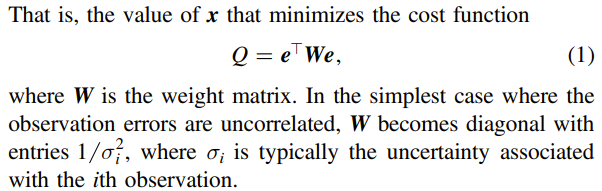

In [ ]:
e = residual_states.flatten().reshape(-1, 1) #198, 1
e_t = e.T #1, 198

W = np.diag(weights.flatten()) #198, #198

q = e_t @ W @ e #1, 1

Q = float(q[0, 0])

print(Q)

4258349.568781689


## Tests

In [ ]:
print(np.mean(np.abs(residual_states)) / arcsec_to_rad)

5.546335252158657
